# Week 2: Numpy, Pandas, Matplotlib, read_files, etc

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Problem 1

In [2]:
# a) Create a NumPy array of 21 temperatures equally spaced from 300 K to 500 K
# np.linspace is appropriate when the number of points and both endpoints are known.
T = np.linspace(300, 500, 21)

# b) Compute spacing between consecutive temperatures
spacing = T[1] - T[0]

# c) Print number of points and spacing
print('Temperatures array (K):')
print(T)
print(f'Number of points: {T.size}')
print(f'Spacing between consecutive temperatures: {spacing:.2f} K')

Temperatures array (K):
[300. 310. 320. 330. 340. 350. 360. 370. 380. 390. 400. 410. 420. 430.
 440. 450. 460. 470. 480. 490. 500.]
Number of points: 21
Spacing between consecutive temperatures: 10.00 K


### Problem 2

In [3]:
# a) Create an array holding 101.325 kPa twelve times
pressure = np.full(12, 101.325)

# b) Compute and print the sum of the array
total_pressure = pressure.sum()

print('Pressure array (kPa):')
print(pressure)
print(f'Sum of pressures: {total_pressure:.3f} kPa')

# Verification using np.isclose instead of == for float comparison
assert np.isclose(total_pressure, 101.325 * 12)

Pressure array (kPa):
[101.325 101.325 101.325 101.325 101.325 101.325 101.325 101.325 101.325
 101.325 101.325 101.325]
Sum of pressures: 1215.900 kPa


### Problem 3

In [4]:
# a) Prediction: Expected value of a[0] is 7 because the array data type is integer,
# so the float 7.9 gets truncated to integer 7.

# b) Run the lines and print a[0]
a = np.zeros(3, dtype=int)
a[0] = 7.9
print(f'a[0] with dtype=int: {a[0]}')
# Explanation: NumPy integer arrays cast assigned floating-point numbers to integers, truncating the fractional part.

# c) Single change to store 7.9 without loss: Set dtype=float (or omit dtype to use default float64).
a_fixed = np.zeros(3, dtype=float)
a_fixed[0] = 7.9
print(f'a_fixed[0] with dtype=float: {a_fixed[0]}')

a[0] with dtype=int: 7
a_fixed[0] with dtype=float: 7.9


### Problem 4

In [5]:
A = 2e11    # s^-1 (pre-exponential factor)
Ea = 65000  # J/mol (activation energy)
R = 8.314   # J/(mol K) (gas constant)

# a) Vectorised calculation of k at T = 300, 350, 400, 450 K
T = np.array([300, 350, 400, 450])  # K
k = A * np.exp(-Ea / (R * T))       # s^-1

print(f'Temperatures: {T} K')
print(f'Rate constants k: {k} s^-1')

# b) Ratio k(400 K) / k(300 K)
ratio = k[2] / k[0]
print(f'Ratio k(400 K) / k(300 K): {ratio:.4f}')

Temperatures: [300 350 400 450] K
Rate constants k: [9.61868950e-01 3.98071216e+01 6.49522841e+02 5.69841318e+03] s^-1
Ratio k(400 K) / k(300 K): 675.2717


### Problem 5

In [6]:
rho = np.array([812.4, 813.1, 811.8, 812.9, 812.2, 813.4])  # kg/m^3

# a) Compute mean density
mean_rho = np.mean(rho)

# b) Compute sample standard deviation (ddof=1)
std_rho = np.std(rho, ddof=1)

# c) Index of reading furthest from mean
dev = np.abs(rho - mean_rho)
furthest_idx = np.argmax(dev)

print(f'Measurements: {rho} kg/m^3')
print(f'Mean density: {mean_rho:.4f} kg/m^3')
print(f'Sample standard deviation: {std_rho:.4f} kg/m^3')
print(f'Index of reading furthest from mean: {furthest_idx}')
print(f'Furthest reading value: {rho[furthest_idx]} kg/m^3 (deviation: {dev[furthest_idx]:.4f} kg/m^3)')

Measurements: [812.4 813.1 811.8 812.9 812.2 813.4] kg/m^3
Mean density: 812.6333 kg/m^3
Sample standard deviation: 0.6022 kg/m^3
Index of reading furthest from mean: 2
Furthest reading value: 811.8 kg/m^3 (deviation: 0.8333 kg/m^3)


### Problem 6

In [7]:
Re = np.array([1500, 5200, 800, 96000, 3500, 42000, 2100])

# a) Boolean mask for turbulent pipes (Re > 4000)
mask_turbulent = Re > 4000

# b) Count turbulent pipes
turbulent_count = mask_turbulent.sum()

# c) Print turbulent Reynolds numbers and count
turbulent_Re = Re[mask_turbulent]

print(f'Turbulent Reynolds numbers: {turbulent_Re}')
print(f'Count of turbulent pipes: {turbulent_count}')

Turbulent Reynolds numbers: [ 5200 96000 42000]
Count of turbulent pipes: 3


### Problem 7

In [8]:
# a) Store 3x3 array (temperatures in K)
table = np.array([
    [420.1, 421.5, 419.8],
    [455.3, 454.9, 455.8],
    [438.6, 439.2, 438.1]
])

# b) Mean of each experiment (row mean, axis=1)
mean_experiment = np.mean(table, axis=1)

# c) Mean of each repeat position (column mean, axis=0)
mean_repeat = np.mean(table, axis=0)

# d) Print results and state axis values
print(f'Mean of each experiment (axis=1): {mean_experiment} K')
print(f'Mean of each repeat position (axis=0): {mean_repeat} K')
# Explanation: axis=1 averages across columns for each row (experiment), whereas axis=0 averages across rows for each column (repeat position).

Mean of each experiment (axis=1): [420.46666667 455.33333333 438.63333333] K
Mean of each repeat position (axis=0): [438.         438.53333333 437.9       ] K


### Problem 8

Number of rows: 11
Maximum absorbance: 0.5206 AU


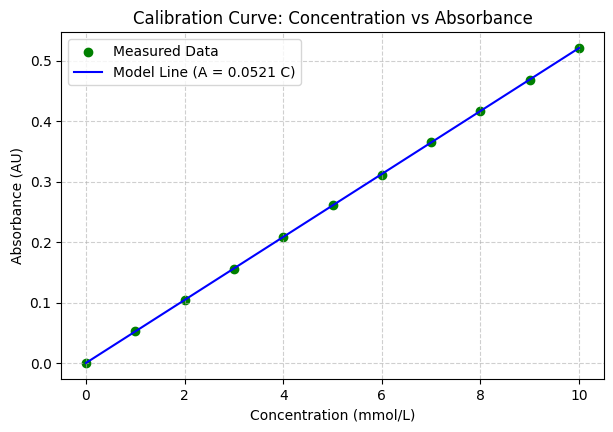

In [9]:
# a) Load calibration.csv columns
conc, abs_val = np.loadtxt('data/calibration.csv', delimiter=',', skiprows=1, unpack=True)

# b) Print number of rows and max absorbance
num_rows = conc.size
max_abs = np.max(abs_val)
print(f'Number of rows: {num_rows}')
print(f'Maximum absorbance: {max_abs:.4f} AU')

# c) Plot measured data and model line A = 0.0521 C
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(conc, abs_val, color='green', marker='o', label='Measured Data')

c_line = np.linspace(0, 10, 100)
a_line = 0.0521 * c_line
ax.plot(c_line, a_line, color='blue', linestyle='-', label='Model Line (A = 0.0521 C)')

ax.set_xlabel('Concentration (mmol/L)')
ax.set_ylabel('Absorbance (AU)')
ax.set_title('Calibration Curve: Concentration vs Absorbance')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Problem 9

In [10]:
# a) Load reactor_runs.csv with pandas
df_reactor = pd.read_csv('data/reactor_runs.csv')

# b) Mean conversion over all runs
mean_conv = df_reactor['conversion'].mean()

# c) Count runs using catalyst "B"
count_b = (df_reactor['catalyst'] == 'B').sum()

# d) Print both results
print(f'Mean conversion over all runs: {mean_conv:.4f}')
print(f'Number of runs using catalyst "B": {count_b}')

Mean conversion over all runs: 0.3671
Number of runs using catalyst "B": 12


### Problem 10

In [11]:
# a) Grid of temperatures 60 to 110 °C in steps of 0.5 °C and Antoine vapour pressure calculation
T_grid = np.arange(60, 110.5, 0.5)  # °C
A, B, C = 8.07131, 1730.63, 233.426   # Antoine constants for water
P_sat = 10 ** (A - B / (C + T_grid))  # mmHg

# b) Boolean mask to find first grid temperature where P_sat > 500 mmHg (no loop)
mask = P_sat > 500
first_T = T_grid[mask][0]

# c) Print temperature
print(f'First temperature where water vapour pressure > 500 mmHg: {first_T:.1f} °C')
print(f'Vapour pressure at {first_T:.1f} °C: {P_sat[mask][0]:.2f} mmHg')

First temperature where water vapour pressure > 500 mmHg: 89.0 °C
Vapour pressure at 89.0 °C: 505.57 mmHg


### Problem 11

In [12]:
Re = np.array([2400, 3100, 5600, 2900, 1500, 3800])
D = np.array([0.025, 0.075, 0.040, 0.030, 0.020, 0.060])  # m

# a) Compound boolean mask: transitional (2100 <= Re <= 4000) AND D < 0.05 m
mask = (Re >= 2100) & (Re <= 4000) & (D < 0.05)

# b) Print indices of selected pipes
selected_indices = np.where(mask)[0]
print(f'Indices of selected pipes: {selected_indices}')
print(f'Selected Pipe details: Re = {Re[mask]}, D = {D[mask]} m')

# c) Comments on rejected pipes:
# Pipe index 0 (Re=2400, D=0.025): Selected (2100 <= Re <= 4000 and D < 0.05)
# Pipe index 1 (Re=3100, D=0.075): Rejected - failed diameter condition (D = 0.075 m >= 0.05 m)
# Pipe index 2 (Re=5600, D=0.040): Rejected - failed Reynolds condition (Re = 5600 > 4000, turbulent)
# Pipe index 3 (Re=2900, D=0.030): Selected (2100 <= Re <= 4000 and D < 0.05)
# Pipe index 4 (Re=1500, D=0.020): Rejected - failed Reynolds condition (Re = 1500 < 2100, laminar)
# Pipe index 5 (Re=3800, D=0.060): Rejected - failed diameter condition (D = 0.060 m >= 0.05 m)

Indices of selected pipes: [0 3]
Selected Pipe details: Re = [2400 2900], D = [0.025 0.03 ] m


### Problem 12

In [13]:
dT1 = np.array([40, 25, 30, 20.000001])  # K
dT2 = np.array([20, 25, 10, 20])         # K

# a) Use np.isclose to find cases where dT1 and dT2 are equal
equal_mask = np.isclose(dT1, dT2)

# b) Compute LMTD with np.where substituting arithmetic mean where equal
with np.errstate(divide='ignore', invalid='ignore'):
    raw_lmtd = (dT1 - dT2) / np.log(dT1 / dT2)

arithmetic_mean = (dT1 + dT2) / 2
lmtd = np.where(equal_mask, arithmetic_mean, raw_lmtd)

# c) Print four LMTD values and number of cases using fallback
fallback_count = equal_mask.sum()
print(f'Equal cases mask: {equal_mask}')
print(f'LMTD values (K): {lmtd}')
print(f'Number of cases using arithmetic mean fallback: {fallback_count}')

# Note for pair 20.000001 vs 20:
# Because np.isclose uses a default relative tolerance (rtol=1e-5), the small difference (1e-6) between 20.000001 and 20 is within tolerance.
# Hence, np.isclose evaluates to True for this pair, triggering the fallback arithmetic mean (20.0000005 K) instead of logarithmic division.

Equal cases mask: [False  True False  True]
LMTD values (K): [28.85390082 25.         18.20478453 20.0000005 ]
Number of cases using arithmetic mean fallback: 2


### Problem 13

In [14]:
k1 = 0.045  # s^-1
T1 = 320.0  # K
k2 = 1.32   # s^-1
T2 = 380.0  # K
R = 8.314   # J/(mol K)

# a) Two-point Arrhenius expression
Ea_J = R * np.log(k2 / k1) / (1/T1 - 1/T2)  # J/mol

# b) Compute and print Ea in kJ/mol
Ea_kJ = Ea_J / 1000  # kJ/mol
print(f'Activation Energy Ea: {Ea_kJ:.2f} kJ/mol')

Activation Energy Ea: 56.93 kJ/mol


### Problem 14

In [15]:
# a) By hand predictions:
# M * v performs element-wise multiplication row by row:
# Row 0: [2.0*4.0, 1.0*2.0] = [8.0, 2.0]
# Row 1: [0.5*4.0, 3.0*2.0] = [2.0, 6.0]
# Output array: [[8.0, 2.0], [2.0, 6.0]]
#
# M @ v performs matrix-vector dot product:
# Row 0: 2.0*4.0 + 1.0*2.0 = 10.0
# Row 1: 0.5*4.0 + 3.0*2.0 = 8.0
# Output array: [10.0, 8.0]

M = np.array([[2., 1.], [0.5, 3.]])
v = np.array([4., 2.])

# b) Compute both in code
res_mult = M * v
res_matmul = M @ v

print('M * v (Element-wise multiplication):')
print(res_mult)
print('M @ v (Matrix-vector product):')
print(res_matmul)

# Confirming predictions using np.allclose
assert np.allclose(res_mult, np.array([[8., 2.], [2., 6.]]))
assert np.allclose(res_matmul, np.array([10., 8.]))

# c) Difference statement:
# The '*' operator performs element-wise multiplication with broadcasting, whereas the '@' operator performs matrix multiplication (dot product).

M * v (Element-wise multiplication):
[[8. 2.]
 [2. 6.]]
M @ v (Matrix-vector product):
[10.  8.]


### Problem 15

In [16]:
# a) Load pipes.csv and compute Reynolds numbers
df_pipes = pd.read_csv('data/pipes.csv')
df_pipes['Re'] = df_pipes['rho_kg_per_m3'] * df_pipes['v_m_per_s'] * df_pipes['D_m'] / df_pipes['mu_Pa_s']

# b) Pipe id and value for largest and smallest Reynolds numbers
max_idx = df_pipes['Re'].idxmax()
min_idx = df_pipes['Re'].idxmin()

max_pipe = df_pipes.loc[max_idx, 'pipe_id']
max_re = df_pipes.loc[max_idx, 'Re']

min_pipe = df_pipes.loc[min_idx, 'pipe_id']
min_re = df_pipes.loc[min_idx, 'Re']

print(f'Largest Reynolds number: Pipe ID {int(max_pipe)} with Re = {max_re:.2f}')
print(f'Smallest Reynolds number: Pipe ID {int(min_pipe)} with Re = {min_re:.4f}')

# c) Count laminar, transitional, and turbulent pipes
n_laminar = (df_pipes['Re'] < 2100).sum()
n_transitional = ((df_pipes['Re'] >= 2100) & (df_pipes['Re'] <= 4000)).sum()
n_turbulent = (df_pipes['Re'] > 4000).sum()

print(f'Laminar pipes (Re < 2100): {n_laminar}')
print(f'Transitional pipes (2100 <= Re <= 4000): {n_transitional}')
print(f'Turbulent pipes (Re > 4000): {n_turbulent}')

Largest Reynolds number: Pipe ID 3 with Re = 249500.00
Smallest Reynolds number: Pipe ID 4 with Re = 9.9474
Laminar pipes (Re < 2100): 3
Transitional pipes (2100 <= Re <= 4000): 1
Turbulent pipes (Re > 4000): 6


### Problem 16

In [17]:
eps = 4.5e-5  # Roughness (m)
L = 10.0      # Pipe length (m)

# a) Compute friction factor f using single np.where, then pressure drop dP
f_laminar = 64.0 / df_pipes['Re']
f_haaland = 1.0 / (-1.8 * np.log10((eps / df_pipes['D_m'] / 3.7)**1.11 + 6.9 / df_pipes['Re']))**2

df_pipes['f'] = np.where(df_pipes['Re'] < 2100, f_laminar, f_haaland)
df_pipes['dP'] = df_pipes['f'] * (L / df_pipes['D_m']) * df_pipes['rho_kg_per_m3'] * (df_pipes['v_m_per_s']**2) / 2.0

# b) Report pipe with largest pressure drop and its dP
max_dp_idx = df_pipes['dP'].idxmax()
largest_dp_pipe = df_pipes.loc[max_dp_idx, 'pipe_id']
largest_dp_val = df_pipes.loc[max_dp_idx, 'dP']

print(f'Pipe with largest pressure drop: Pipe ID {int(largest_dp_pipe)} with dP = {largest_dp_val:.2f} Pa')

# c) Verification of one laminar and one turbulent friction factor by hand
# Laminar Verification (Pipe 6: Re = 998):
pipe6_f_code = df_pipes.loc[5, 'f']
pipe6_f_hand = 64.0 / 998.0
print('[Verification] Laminar Pipe 6 (Re = 998):')
print(f'  Code f = {pipe6_f_code:.6f}, Hand f = 64 / 998 = {pipe6_f_hand:.6f}')

# Turbulent Verification (Pipe 2: Re = 59880, D = 0.05 m):
pipe2_f_code = df_pipes.loc[1, 'f']
term = (eps / 0.05 / 3.7)**1.11 + 6.9 / 59880.0
pipe2_f_hand = 1.0 / (-1.8 * np.log10(term))**2
print('[Verification] Turbulent Pipe 2 (Re = 59880, D = 0.05 m):')
print(f'  Code f = {pipe2_f_code:.6f}, Hand f = {pipe2_f_hand:.6f}')

assert np.isclose(pipe6_f_code, pipe6_f_hand)
assert np.isclose(pipe2_f_code, pipe2_f_hand)

Pipe with largest pressure drop: Pipe ID 4 with dP = 145920.00 Pa
[Verification] Laminar Pipe 6 (Re = 998):
  Code f = 0.064128, Hand f = 64 / 998 = 0.064128
[Verification] Turbulent Pipe 2 (Re = 59880, D = 0.05 m):
  Code f = 0.022885, Hand f = 0.022885


### Problem 17

In [18]:
# a) Put Antoine constants as (3, 1) columns and temperature grid as (1, 501) row
A = np.array([[8.07131], [8.20417], [6.90565]])
B = np.array([[1730.63], [1642.89], [1211.033]])
C = np.array([[233.426], [230.30], [220.79]])

# Temperature grid from 60 to 110 °C in 0.1 °C steps
T_grid = np.arange(60, 110.05, 0.1).reshape(1, 501)  # (1, 501) row vector

# Broadcast calculation for 3 x 501 array of vapour pressures (mmHg)
P_sat_table = 10 ** (A - B / (C + T_grid))

# b) For each component, find first grid temperature at which Psat > 760 mmHg
compounds = ['Water', 'Ethanol', 'Benzene']
known_nbp = np.array([100.0, 78.37, 80.10])  # °C
found_nbp = []

print('First temperature where P_sat > 760 mmHg:')
for i, comp in enumerate(compounds):
    mask = P_sat_table[i] > 760
    t_first = T_grid[0, mask][0]
    found_nbp.append(t_first)
    print(f'  {comp}: {t_first:.1f} °C (Known NBP: {known_nbp[i]} °C)')

# c) Report maximum absolute error against known normal boiling points
found_nbp = np.array(found_nbp)
max_abs_error = np.max(np.abs(found_nbp - known_nbp))
print(f'Maximum absolute error against known NBPs: {max_abs_error:.3f} °C')

First temperature where P_sat > 760 mmHg:
  Water: 100.0 °C (Known NBP: 100.0 °C)
  Ethanol: 78.4 °C (Known NBP: 78.37 °C)
  Benzene: 80.1 °C (Known NBP: 80.1 °C)
Maximum absolute error against known NBPs: 0.030 °C


### Problem 18

In [19]:
# a) Seed generator with 42, draw 100,000 samples of Cd then dP, compute Q
rng = np.random.default_rng(42)

A_orifice = 5e-4    # m^2
rho_fluid = 998.0   # kg/m^3

Cd_samples = rng.normal(0.61, 0.01, 100000)
dP_samples = rng.normal(25000, 1000, 100000)  # Pa

# Vectorised computation of Q (m^3/s)
Q_samples = Cd_samples * A_orifice * np.sqrt(2 * dP_samples / rho_fluid)

# b) Report mean, standard deviation, and relative standard deviation (%)
mean_Q = np.mean(Q_samples)
std_Q = np.std(Q_samples, ddof=1)
rel_std_pct = (std_Q / mean_Q) * 100

print(f'Mean flow rate Q: {mean_Q:.6e} m^3/s')
print(f'Standard deviation of Q: {std_Q:.6e} m^3/s')
print(f'Relative standard deviation of Q: {rel_std_pct:.4f}%')

# c) Linear-propagation estimate and explanation of the factor 1/2
sigma_Cd_rel = 0.01 / 0.61
sigma_dP_rel = 1000 / 25000
linear_prop_rel_std = np.sqrt(sigma_Cd_rel**2 + (0.5 * sigma_dP_rel)**2) * 100

print(f'Linear-propagation estimated relative std: {linear_prop_rel_std:.4f}%')

# Explanation of factor 1/2:
# In the orifice equation, Q is proportional to sqrt(dP) = dP^(1/2). By first-order Taylor expansion error propagation for y = x^n,
# the relative uncertainty sigma_y/y ≈ |n| * (sigma_x/x). Since n = 1/2 for the square-root dependency on dP, the relative uncertainty of dP is multiplied by 1/2.

Mean flow rate Q: 2.158369e-03 m^3/s
Standard deviation of Q: 5.596104e-05 m^3/s
Relative standard deviation of Q: 2.5927%
Linear-propagation estimated relative std: 2.5860%


### Problem 19

In [ ]:
# Save dirty.csv file
dirty_csv_data = """t_min,T_K
0,350.2
5,
10,352.8
15,353.9
20,
25,356.1
30,357.0
35,
"""

with open('dirty.csv', 'w') as f:
    f.write(dirty_csv_data)

# a) Load file with np.genfromtxt so missing values become nan
data_dirty = np.genfromtxt('dirty.csv', delimiter=',', skip_header=1)
t_min_col = data_dirty[:, 0]
T_K_col = data_dirty[:, 1]

# b) Report missing temperature count, nan-aware mean, and complete rows count
missing_count = np.isnan(T_K_col).sum()
nan_mean_T = np.nanmean(T_K_col)
complete_rows = (~np.isnan(data_dirty).any(axis=1)).sum()

print(f'Number of missing temperature values: {missing_count}')
print(f'Nan-aware mean temperature: {nan_mean_T:.2f} K')
print(f'Number of complete rows: {complete_rows}')

# A plain .mean() fails because standard arithmetic operations involving NaN propagate NaN, causing the result to evaluate to NaN.
print(f'Plain .mean() result: {T_K_col.mean()}')

Number of missing temperature values: 3
Nan-aware mean temperature: 354.00 K
Number of complete rows: 5
Plain .mean() result: nan


### Problem 20

In [21]:
# a) Seed generator with 0, C = 0 to 10 mmol/L (11 points), set A = 0.0521 C + noise
rng = np.random.default_rng(0)
C = np.linspace(0, 10, 11)  # mmol/L
A_noisefree = 0.0521 * C
noise = rng.normal(0, 0.004, size=11)
A_noisy = A_noisefree + noise

# b) Compute largest absolute deviation from noise-free line and test specification
abs_deviations = np.abs(A_noisy - A_noisefree)
max_dev = np.max(abs_deviations)
spec = 0.01  # AU

satisfies_spec = max_dev <= spec

print('Concentrations (mmol/L):')
print(C)
print('Noisy Absorbance values:')
print(A_noisy)
print(f'Largest absolute deviation: {max_dev:.6f} AU')
print(f'Does it satisfy 0.01 AU specification? {satisfies_spec} (Max dev {max_dev:.6f} <= {spec} AU)')

# c) Explanation for seed guarantee:
# Using the same seed initializes the pseudo-random number generator with an identical state, ensuring it produces the exact same sequence of random numbers and final verdict on any computer.

Concentrations (mmol/L):
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Noisy Absorbance values:
[5.02920884e-04 5.15715805e-02 1.06761691e-01 1.56719600e-01
 2.06257323e-01 2.61946380e-01 3.17816000e-01 3.68488324e-01
 4.13985059e-01 4.63838314e-01 5.18506902e-01]
Largest absolute deviation: 0.005216 AU
Does it satisfy 0.01 AU specification? True (Max dev 0.005216 <= 0.01 AU)
